## Hypothesis 5: Customer Support Experience and Churn

### Observation



The number of support tickets appears similar between churned and non-churned customers. However, support interactions remain an important area for further investigation because ticket count alone may not capture customer satisfaction.

Hypothesis

Customer churn may be influenced more by support quality (such as sentiment, resolution time, and ticket reopening) than by the number of support tickets alone.

Business Implication

The company should monitor customer sentiment, ticket resolution times, and repeat complaints to identify customers who may be at elevated risk of churn.

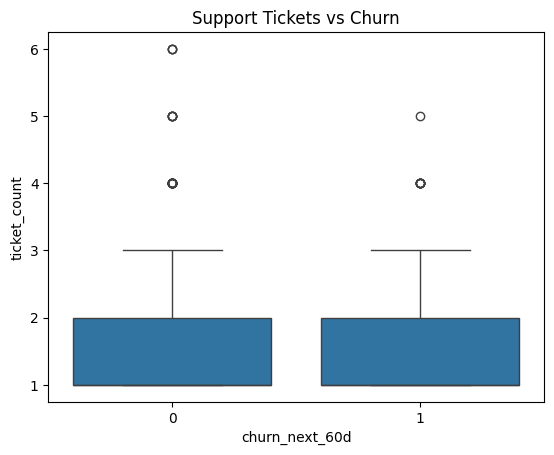

In [59]:
sns.boxplot(
    data=support_churn,
    x='churn_next_60d',
    y='ticket_count'
)

plt.title('Support Tickets vs Churn')
plt.show()

In [58]:
support_churn = churn.merge(
    support_summary,
    on='customer_id',
    how='left'
)

support_churn.head()

,customer_id,snapshot_date,churn_next_60d,split,ticket_count,avg_sentiment,avg_resolution_hours,reopened_count
0,CUST00001,2025-09-30,1,train,2.0,0.14,4.35,0.0
1,CUST00002,2025-09-30,0,train,1.0,0.00,1.00,0.0
2,CUST00003,2025-09-30,1,train,NaN,NaN,NaN,NaN
3,CUST00004,2025-09-30,1,train,NaN,NaN,NaN,NaN
4,CUST00005,2025-09-30,0,train,1.0,-1.00,37.70,0.0


In [57]:
support_summary = support.groupby('customer_id').agg(
    ticket_count=('ticket_id', 'count'),
    avg_sentiment=('sentiment_score', 'mean'),
    avg_resolution_hours=('resolution_hours', 'mean'),
    reopened_count=('reopened', 'sum')
).reset_index()

support_summary.head()

,customer_id,ticket_count,avg_sentiment,avg_resolution_hours,reopened_count
0,CUST00001,2,0.14,4.35,0
1,CUST00002,1,0.00,1.00,0
2,CUST00005,1,-1.00,37.70,0
3,CUST00006,2,-0.68,17.60,1
4,CUST00008,1,0.08,6.00,0


In [56]:
support.info()

<class 'pandas.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   str    
 1   customer_id       1921 non-null   str    
 2   ticket_date       1921 non-null   str    
 3   issue_type        1921 non-null   str    
 4   support_channel   1921 non-null   str    
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), str(5)
memory usage: 120.2 KB


In [55]:
support = pd.read_csv("../data/support_tickets.csv")

support.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


## Hypothesis 4: Customer Value and Churn

### Observation

Customers who churned tend to have lower total spending than customers who remained active.

### Hypothesis

Lower-spending customers are at higher risk of churn.

### Business Implication

The company should identify low-value customers early and evaluate whether targeted retention efforts can increase long-term customer value.


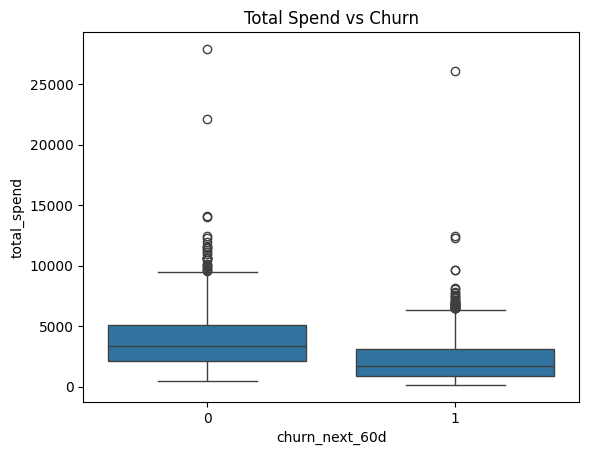

In [28]:
sns.boxplot(
    data=analysis_df,
    x='churn_next_60d',
    y='total_spend'
)

plt.title('Total Spend vs Churn')
plt.show()

## Hypothesis 3: Purchase Frequency and Churn

### Observation

The Total Orders vs Churn boxplot shows that churned customers generally have fewer orders than non-churned customers.

### Hypothesis

Customers with lower purchase frequency are more likely to churn.

### Business Implication

Increasing purchase frequency through engagement campaigns, reminders, or loyalty programs may help reduce churn risk.


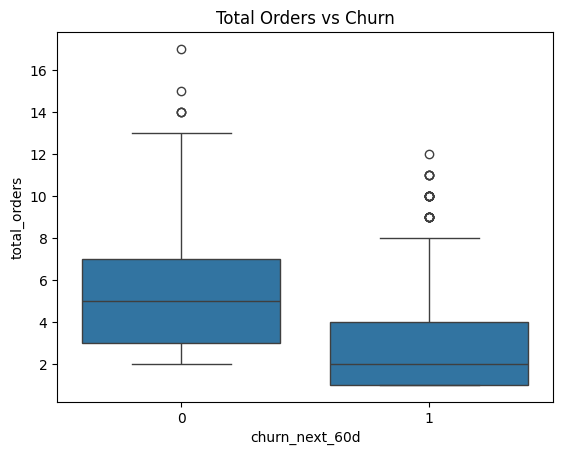

In [29]:
sns.boxplot(
    data=analysis_df,
    x='churn_next_60d',
    y='total_orders'
)

plt.title('Total Orders vs Churn')
plt.show()

In [30]:
analysis_df = churn.merge(
    order_summary,
    on='customer_id',
    how='left'
)

analysis_df.head()

,customer_id,snapshot_date,churn_next_60d,split,total_orders,total_spend,avg_discount,avg_delivery_days,return_count
0,CUST00001,2025-09-30,1,train,6,2955.57,0.363333,3.500000,1
1,CUST00002,2025-09-30,0,train,3,1713.10,0.190000,3.333333,0
2,CUST00003,2025-09-30,1,train,1,649.98,0.470000,2.000000,0
3,CUST00004,2025-09-30,1,train,1,1604.04,0.160000,5.000000,0
4,CUST00005,2025-09-30,0,train,6,3910.43,0.388333,5.166667,0


In [31]:
order_summary = orders.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),
    total_spend=('gross_amount', 'sum'),
    avg_discount=('discount_pct', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    return_count=('returned', 'sum')
).reset_index()

order_summary.head()

,customer_id,total_orders,total_spend,avg_discount,avg_delivery_days,return_count
0,CUST00001,6,2955.57,0.363333,3.500000,1
1,CUST00002,3,1713.10,0.190000,3.333333,0
2,CUST00003,1,649.98,0.470000,2.000000,0
3,CUST00004,1,1604.04,0.160000,5.000000,0
4,CUST00005,6,3910.43,0.388333,5.166667,0


## Hypothesis 2: Age Group and Churn

### Observation

Customers across all age groups exhibit churn behaviour. The 25–34 age group contributes the largest number of churned customers because it represents the largest customer segment in the dataset.

### Hypothesis

Age group alone is not a strong predictor of churn. Customer purchasing and engagement behaviour are likely stronger indicators of churn risk.

### Business Implication

The company should prioritize behavioural segmentation and customer activity metrics over demographic attributes when designing retention campaigns.


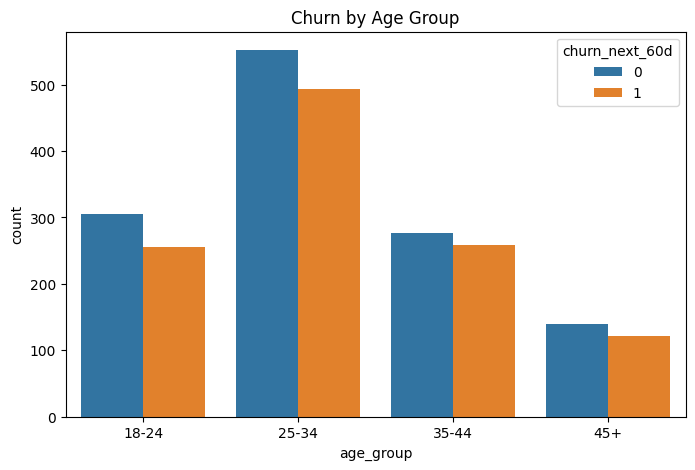

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_churn,
    x="age_group",
    hue="churn_next_60d"
)

plt.title("Churn by Age Group")
plt.show()

In [33]:
customer_churn = customers.merge(
    churn,
    on="customer_id",
    how="left"
)

customer_churn.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train


In [34]:
orders.duplicated().sum()

np.int64(0)

In [35]:
customers.duplicated().sum()

np.int64(0)

In [36]:
orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

## Hypothesis 1: City Tier and Churn

### Observation

Churn is observed across customers from Tier 1, Tier 2, and Tier 3 cities. The distribution of churned and non-churned customers appears relatively similar across city tiers.

### Hypothesis

Customer churn is influenced more by customer behaviour and engagement than by city tier alone.

### Business Implication

Retention efforts should focus on behavioural signals such as purchase frequency, spending patterns, support interactions, and website engagement rather than targeting customers solely based on geographic city tier.


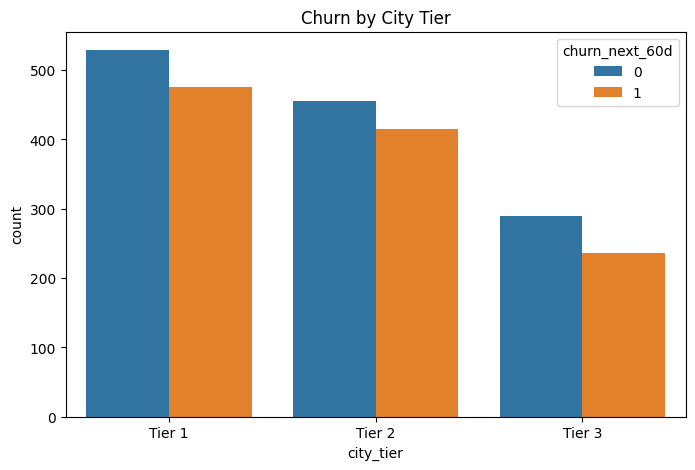

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_churn,
    x='city_tier',
    hue='churn_next_60d'
)

plt.title('Churn by City Tier')
plt.show()

In [38]:
customers.isnull().sum()

customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

In [39]:
customer_churn = customers.merge(
    churn,
    on='customer_id',
    how='left'
)

customer_churn.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train


In [40]:
churn['churn_next_60d'].value_counts(normalize=True) * 100

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64

In [41]:
churn['churn_next_60d'].value_counts()

churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

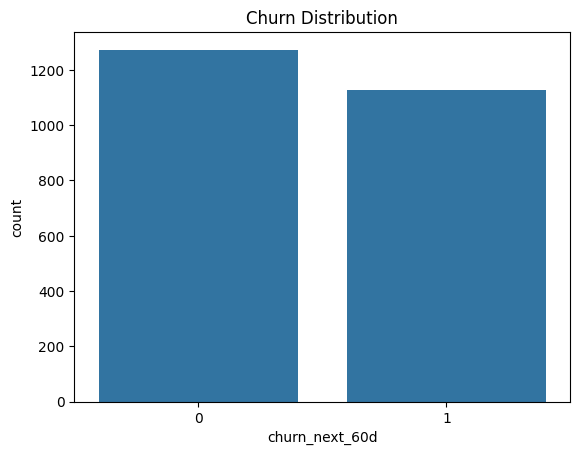

In [42]:
sns.countplot(data=churn, x='churn_next_60d')
plt.title('Churn Distribution')
plt.show()

In [43]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     2400 non-null   str  
 1   snapshot_date   2400 non-null   str  
 2   churn_next_60d  2400 non-null   int64
 3   split           2400 non-null   str  
dtypes: int64(1), str(3)
memory usage: 75.1 KB


In [44]:
churn.head()

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


In [45]:
web_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   snapshot_date        2400 non-null   str  
 2   sessions_30d         2400 non-null   int64
 3   product_views_30d    2400 non-null   int64
 4   cart_adds_30d        2400 non-null   int64
 5   wishlist_adds_30d    2400 non-null   int64
 6   abandoned_carts_30d  2400 non-null   int64
 7   email_opens_30d      2400 non-null   int64
 8   campaign_clicks_30d  2400 non-null   int64
 9   last_visit_days_ago  2400 non-null   int64
dtypes: int64(8), str(2)
memory usage: 187.6 KB


In [46]:
customers.isnull().sum()

customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

In [47]:
orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

In [48]:
intervention.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   customer_id             2400 non-null   str  
 1   snapshot_date           2400 non-null   str  
 2   last_campaign_received  2400 non-null   str  
 3   last_campaign_cost      2400 non-null   int64
 4   manual_priority_bucket  2400 non-null   str  
dtypes: int64(1), str(4)
memory usage: 93.9 KB


In [49]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     2400 non-null   str  
 1   snapshot_date   2400 non-null   str  
 2   churn_next_60d  2400 non-null   int64
 3   split           2400 non-null   str  
dtypes: int64(1), str(3)
memory usage: 75.1 KB


In [50]:
support.info()

<class 'pandas.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   str    
 1   customer_id       1921 non-null   str    
 2   ticket_date       1921 non-null   str    
 3   issue_type        1921 non-null   str    
 4   support_channel   1921 non-null   str    
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), str(5)
memory usage: 120.2 KB


In [51]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  str    
 1   customer_id    10009 non-null  str    
 2   order_date     10009 non-null  str    
 3   category       10009 non-null  str    
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 782.1 KB


In [52]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   signup_date          2400 non-null   str  
 2   city_tier            2400 non-null   str  
 3   age_group            2400 non-null   str  
 4   acquisition_channel  2400 non-null   str  
 5   loyalty_tier         1014 non-null   str  
 6   preferred_category   2400 non-null   str  
 7   skin_type            1999 non-null   str  
 8   marketing_consent    2400 non-null   str  
dtypes: str(9)
memory usage: 168.9 KB


In [53]:
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
support = pd.read_csv("../data/support_tickets.csv")
churn = pd.read_csv("../data/churn_labels.csv")
intervention = pd.read_csv("../data/intervention_history.csv")
web_events = pd.read_csv("../data/web_events_snapshot.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support:", support.shape)
print("Churn:", churn.shape)
print("Intervention:", intervention.shape)
print("Web Events:", web_events.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support: (1921, 8)
Churn: (2400, 4)
Intervention: (2400, 5)
Web Events: (2400, 10)


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)